# monitor photom

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


## Download


In [2]:
/bin/rm -f pcad*fits aca*fits
download_chandra_obsid 11022 adat
mv -fv 11022/secondary/aspect/*adat* .
gunzip -f *fits.gz 


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  adat     fits        2 Mb  ####################          < 1 s  34114.5 kb/s

`11022/secondary/aspect/pcadf383724410N002_adat71.fits.gz' -> `./pcadf383724410N002_adat71.fits.gz'


## Merge files together (if necessary)

In [3]:
/bin/ls *adat71.fits > adat71.lis
dmmerge infile=@adat71.lis outfile=pcad_adat71.fits clob+

## Run monitor_photom

In [4]:
monitor_photom infile=pcad_adat71.fits outfile=monitor_lc.fits verbose=1 clob+

monitor_photom
          infile = pcad_adat71.fits
         outfile = monitor_lc.fits
      dark_ratio = 0.005
  min_dark_limit = 80
   min_dark_meas = 10
max_dither_motion = 10
         verbose = 1
         clobber = yes
            mode = ql

Filtering image data (cosmic ray removal)...
Stacking dark current data...
Average counts  (e-) = 29884.8366577
Warm dark limit (e-) = 149.424183288
Warm pixel at CCD (row,col) = (-6,8)	 Dark current (e-) = 390.0
Warm pixel at CCD (row,col) = (-13,9)	 Dark current (e-) = 320.0
Warm pixel at CCD (row,col) = (-7,10)	 Dark current (e-) = 160.0
Warm pixel at CCD (row,col) = (-11,11)	 Dark current (e-) = 215.0
Warm pixel at CCD (row,col) = (-7,11)	 Dark current (e-) = 280.0
Warm pixel at CCD (row,col) = (-5,13)	 Dark current (e-) = 345.0
Warm pixel at CCD (row,col) = (-6,16)	 Dark current (e-) = 355.0
Warm pixel at CCD (row,col) = (-9,17)	 Dark current (e-) = 185.0
Warm pixel at CCD (row,col) = (-9,18)	 Dark current (e-) = 215.0


## Examine Results


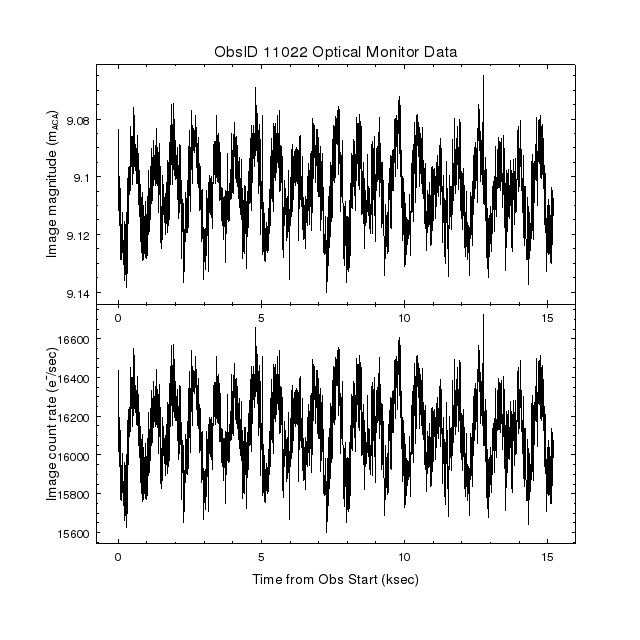

In [5]:
cat << EOM > c1.py
lc = read_file("monitor_lc.fits")
mag = lc.get_column("mag").values
toff = lc.get_column("time").values
toff = (toff-toff[0])/1000.0

add_curve( toff, mag, {'symbol.style' : 'none'} )
set_plot_ylabel("Image magnitude (m_{ACA})")
set_plot_title("ObsID 11022 Optical Monitor Data")
reverse_axes( Y_AXIS )

split(2)
counts =  lc.get_column("count_rate").values
add_curve( toff, counts, {'symbol.style': 'none'})
set_plot_ylabel("Image count rate (e^-/sec)")
set_plot_xlabel("Time from Obs Start (ksec)")
print_window("chips_01.png","export.clobber=True")
quit()
EOM

chips -n c1.py
display < chips_01.png


## Check Freq

In [6]:
dmstat "monitor_lc.fits[cols counts]" | grep mean

   mean:	27347.435057 


In [7]:
dmtcalc monitor_lc.fits lc0.fits expr='c0=counts-27347.435057' clob+

In [8]:
apowerspectrum lc0.fits'[cols time,c0]' none powerspec.fits crop=yes clob+ 

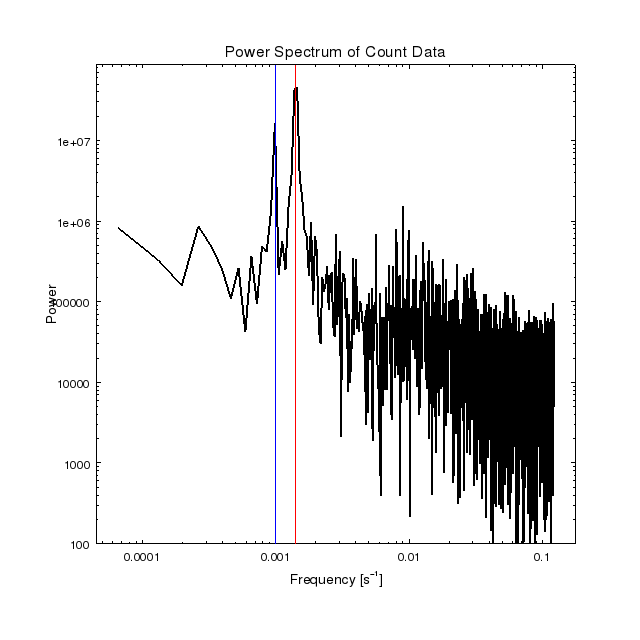

In [9]:
cat << EOM > c2.py
psout = read_file("powerspec.fits")
freq = psout.get_column("frequency").values
pwr = psout.get_column("data").values
add_curve(freq, pwr, "symbol.style=none line.thickness=2")
log_scale(XY_AXIS)
limits(Y_AXIS, 100, AUTO) 

add_vline( 1.0 / 707.1, "color=red" )
add_vline( 1.0 / 1000.0, "color=blue" )

set_plot_xlabel("Frequency [s^{-1}]")
set_plot_ylabel("Power")
set_plot_title("Power Spectrum of Count Data")
print_window("chips_02.png","export.clobber=True")
quit()
EOM

chips -n c2.py
display < chips_02.png



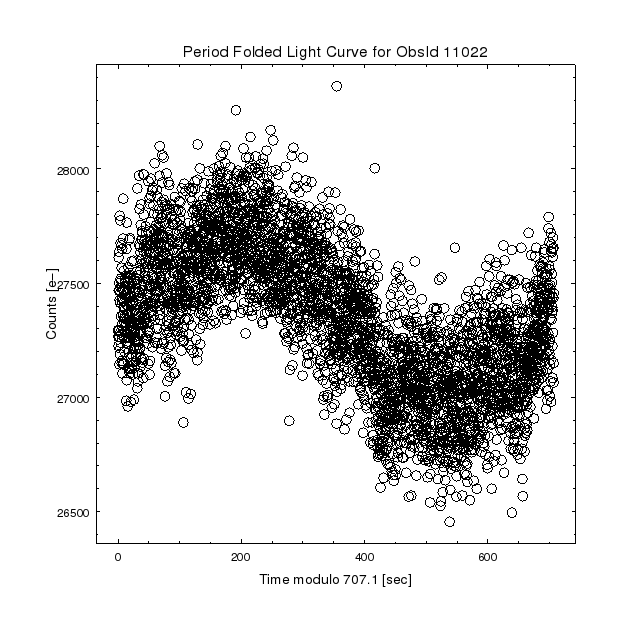

In [10]:
cat << EOM > c3.py
tab = read_file("monitor_lc.fits")
tt = tab.get_column("time").values
cc = tab.get_column("counts").values
fold = np.mod( tt, 707.1 )

add_curve( fold, cc )
set_curve( "line.style=none symbol.style=circle symbol.fill=False")
set_plot_xlabel("Time modulo 707.1 [sec]")
set_plot_ylabel("Counts [e-]")
set_plot_title("Period Folded Light Curve for ObsId 11022")
print_window("chips_03.png","export.clobber=True")
quit()
EOM

chips -n c3.py
display < chips_03.png


---
## Problem cases


In [11]:
/bin/rm -rf 4924
download_chandra_obsid 4924 adat

dmmerge infile="4924/secondary/aspect/*adat71.fits.gz" outfile=pcad4924_adat71.fits clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  adat     fits       11 Kb  ####################          < 1 s  1806.7 kb/s
  adat     fits        2 Mb  ####################          < 1 s  55998.2 kb/s
  adat     fits        1 Mb  ####################          < 1 s  42583.2 kb/s
  adat     fits        2 Mb  ####################          < 1 s  51116.5 kb/s
  adat     fits      905 Kb  ####################          < 1 s  33795.7 kb/s
  adat     fits        1 Mb  ####################          < 1 s  28473.3 kb/s

      Total download size for ObsId 4924 = 8 Mb
      Total download time for ObsId 4924 = < 1 s



In [12]:
monitor_photom infile=pcad4924_adat71.fits \
  outfile=monitor4924_lc.fits clob+ verb=1

monitor_photom
          infile = pcad4924_adat71.fits
         outfile = monitor4924_lc.fits
      dark_ratio = 0.005
  min_dark_limit = 80
   min_dark_meas = 10
max_dither_motion = 10
         verbose = 1
         clobber = yes
            mode = ql

Filtering image data (cosmic ray removal)...
Stacking dark current data...
Average counts  (e-) = 2137.99610566
Warm dark limit (e-) = 80.0
Warm pixel at CCD (row,col) = (-18,10)	 Dark current (e-) = 85.0
Warm pixel at CCD (row,col) = (-17,11)	 Dark current (e-) = 325.0
Warm pixel at CCD (row,col) = (-11,11)	 Dark current (e-) = 615.0
Warm pixel at CCD (row,col) = (-15,12)	 Dark current (e-) = 105.0
Warm pixel at CCD (row,col) = (-8,16)	 Dark current (e-) = 115.0
Warm pixel at CCD (row,col) = (-10,17)	 Dark current (e-) = 105.0
Warm pixel at CCD (row,col) = (-17,19)	 Dark current (e-) = 170.0
Warm pixel at CCD (row,col) = (-14,20)	 Dark current (e-) = 130.0
Warm pixel at CCD (row,col) = (-13,20)	 Dark current (e-) = 175.0
Warm pixel at C

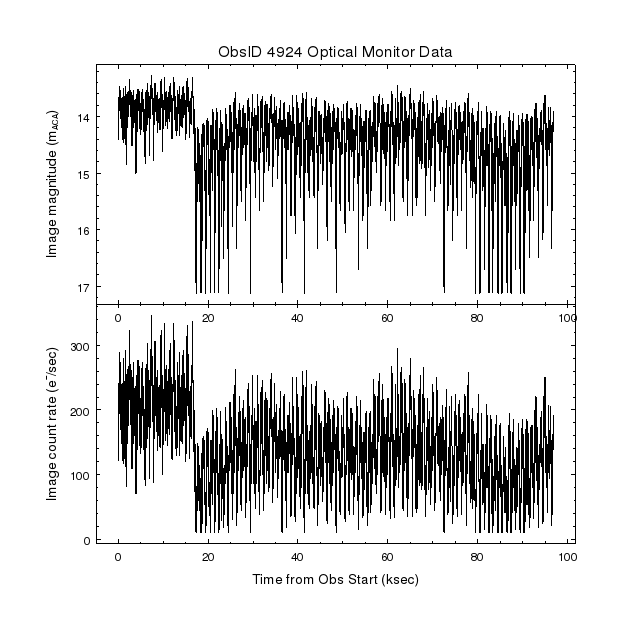

In [13]:
cat << EOM > c4.py
lc = read_file("monitor4924_lc.fits")
mag = lc.get_column("mag").values
toff = lc.get_column("time").values
toff = (toff-toff[0])/1000.0

add_curve( toff, mag, {'symbol.style' : 'none'} )
set_plot_ylabel("Image magnitude (m_{ACA})")
set_plot_title("ObsID 4924 Optical Monitor Data")
reverse_axes( Y_AXIS )

split(2)
counts =  lc.get_column("count_rate").values
add_curve( toff, counts, {'symbol.style': 'none'})
set_plot_ylabel("Image count rate (e^-/sec)")
set_plot_xlabel("Time from Obs Start (ksec)")
print_window("chips_04.png","export.clobber=True")
quit()
EOM

chips -n c4.py
display < chips_04.png


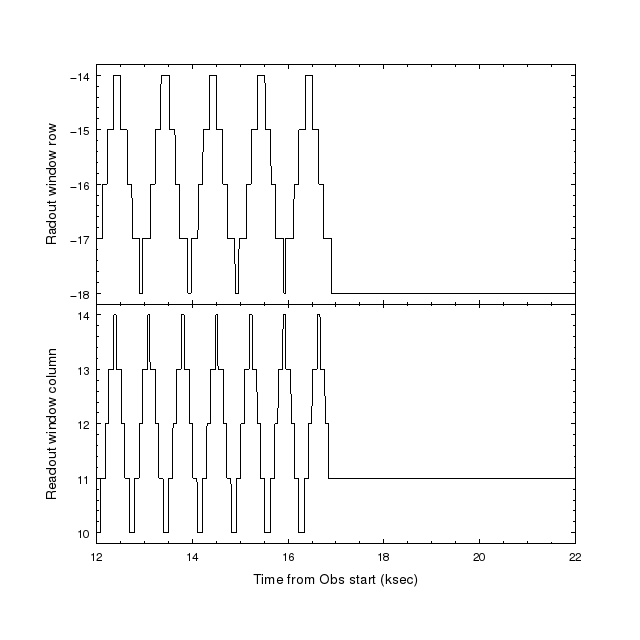

In [14]:
cat << EOM > c5.py
dat = read_file("pcad4924_adat71.fits")
toff = dat.get_column("time").values
row = dat.get_column("img_row0").values
col = dat.get_column("img_col0").values
toff = (toff-toff[0])/1000.0

add_curve( toff, row, {'symbol.style':'none'} )
set_plot_ylabel("Radout window row")
hide_axis("ax1")

split(2)
add_curve( toff, col, {'symbol.style':'none'} )
bind_axes("plot1", "ax1", "plot2", "ax1")
set_plot_ylabel("Readout window column")
set_plot_xlabel("Time from Obs start (ksec)")
limits( X_AXIS, 12, 22 )
print_window("chips_05.png","export.clobber=True")
quit()
EOM

chips -n c5.py
display < chips_05.png


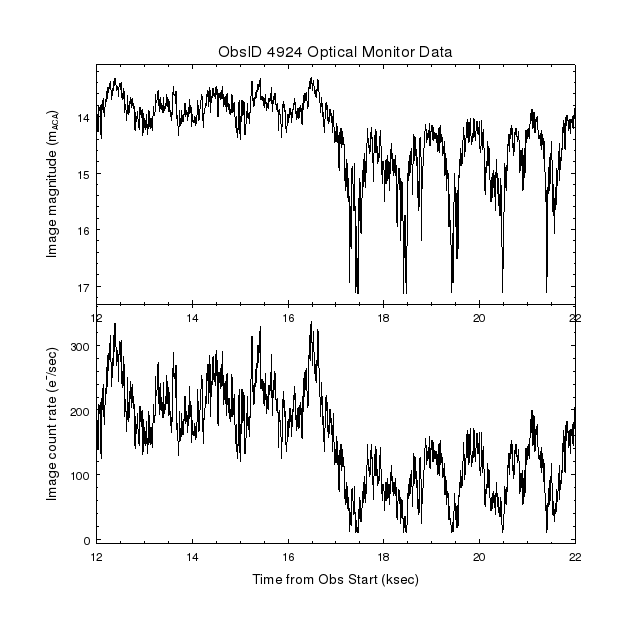

In [15]:
cat << EOM > c6.py
lc = read_file("monitor4924_lc.fits")
mag = lc.get_column("mag").values
toff = lc.get_column("time").values
toff = (toff-toff[0])/1000.0

add_curve( toff, mag, {'symbol.style' : 'none'} )
set_plot_ylabel("Image magnitude (m_{ACA})")
set_plot_title("ObsID 4924 Optical Monitor Data")
reverse_axes( Y_AXIS )

split(2)
counts =  lc.get_column("count_rate").values
add_curve( toff, counts, {'symbol.style': 'none'})
set_plot_ylabel("Image count rate (e^-/sec)")
set_plot_xlabel("Time from Obs Start (ksec)")
bind_axes("plot1", "ax1", "plot2", "ax1")
limits( X_AXIS, 12, 22 )
print_window("chips_06.png","export.clobber=True")
quit()
EOM

chips -n c6.py
display < chips_06.png
